# **Analysis and Visualization of Complex Data**
## Exercise 1 - Create your own personal word cloud

Danilo III O. Gonzales (SN: 29225) <br>
Masters Course in Green Data Science

### AI Use Declaration and Prompts Used

I acknowledge that I used **Gemini Pro** as an AI tool provided under my university access to assist in the preparation of this work. All AI-generated suggestions were carefully reviewed, edited, and verified by me to ensure accuracy, originality, and compliance with university academic integrity policies. The prompts used during this process included:

- `What python library can I use to extract words from .pdf to .txt for wordcloud and how to implement it?`

I take full responsibility for the final submitted work and confirm that the use of AI aligns with the guidelines established by the university. I am also willing to provide the full AI conversation transcript upon request for transparency and verification purposes.

### Install and Import Necessary Package

In [17]:
pip install -q pypdf wordcloud matplotlib pdfplumber

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from PIL import Image
import pdfplumber

### Extract Text from LinkedIn PDF

In [19]:
pdf_path = "./data/dgonzales_linkedin.pdf"

text = ""
with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        text += page.extract_text()

# Preview first 500 characters
print(text[:500])

Contact Danilo III Gonzales
dogonzalesiii@gmail.com
MSc Student, Data Science in Agriculture, Food, Forestry and
www.linkedin.com/in/dogonzales Environment
(LinkedIn)
Lisbon Metropolitan Area
Top Skills
Summary
Spatial Data
Licensed Agricultural and Biosystems Engineer in the Philippines
ArcGIS Pro
with specialization in agricultural meteorology and controlled
Automated Machine Learning
(AutoML) environment engineering. Experienced in project management, GIS
and remote sensing, indoor farming an


### Define Custom Stop Words


In [20]:
stopwords = set(STOPWORDS)

custom_words = [
    # Personal info
    "danilo", "gonzales", "contact", "gmail", "com", "linkedin", "title", "dost", "pcaarrd", "project", "iii",

    # Generic CV words
    "summary", "experience", "education", "student", "msc", "level", 
    "masters", "degree", "university", "currently", "pro", "arc"

    # Common CV verbs
    "prepared", "supported", "using", "designed", "conducted", 
    "organized", "implemented", "coordinating", "managing", 
    "produced", "led",

    # Document / output terms
    "reports", "report", "presentations", "publication",
    "materials", "documentation",

    # Time-related words
    "august", "september", "january", "february", "july",
    "months", "years", 

    # Broad/duplicate terms and other nonrelevant terms
    "science", "page", "agricultural", "biosystems", "agency", "department", "specialization", "system", "systems",

    # Links / locations / symbols
    "www", "http", "https", "org", "in", "sarai", "msc", "calabarzon", "cl", "seams",
    "philippine", "philippines", "lisbon", "los", "baños", "ielts", 
]

# Force everything lowercase — catches any typos
stopwords.update(w.lower() for w in custom_words)

### Generate a Basic Word Cloud

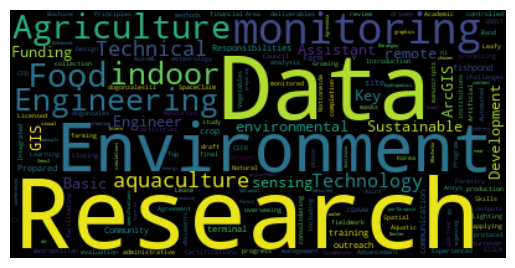

In [21]:
wordcloud = WordCloud(stopwords=stopwords).generate(text)

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Wordcloud with Added Customization

Customizations:
1. Limit maximum font size.
2. Set background color to white.
3. Set image dimensions.
4. Added stopwords.

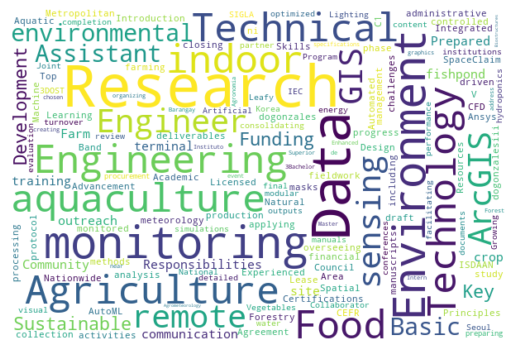

In [22]:
wordcloud = WordCloud(
    stopwords=stopwords,
    max_font_size=70,
    background_color="white",
    width=600,
    height=400
).generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

### Load Shape Mask

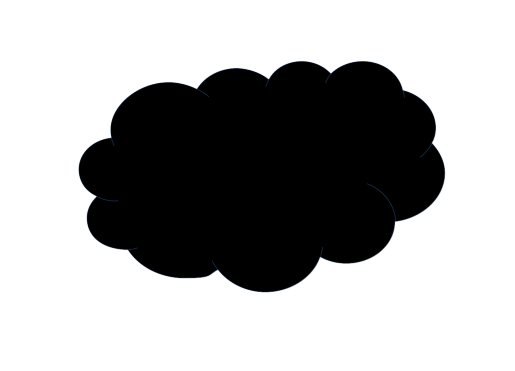

In [23]:
cloud_mask = np.array(Image.open("./cloud.png"))

plt.imshow(cloud_mask)
plt.axis("off")
plt.show()

### Generate Word Cloud with Mask

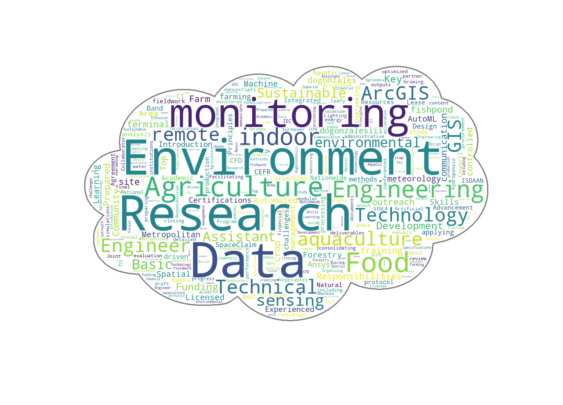

In [24]:
wc = WordCloud(
    background_color="white",
    max_words=200,
    mask=cloud_mask,
    stopwords=stopwords,
    contour_width=2,
    repeat=True,
    max_font_size=120,
    contour_color="grey",
)

wc.generate(text)
wc.to_file("masked_wordcloud.png")

plt.figure(figsize=[10, 5])
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()